/tmp/ipykernel_441311/4050192458.py:40: RuntimeWarning: invalid value encountered in log10
  abs_mag = g + 5 * np.log10(parallax / 1000) + 5


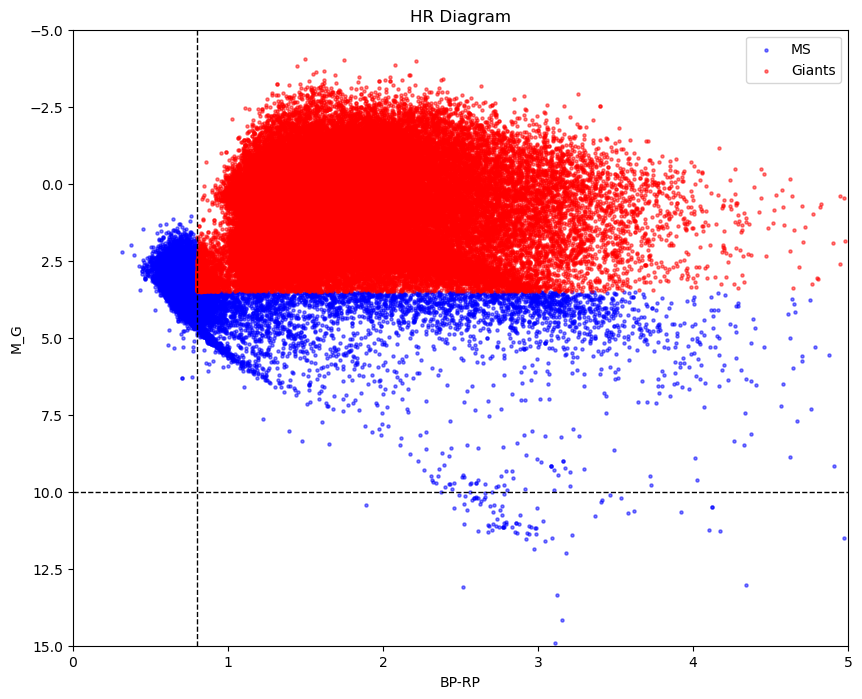

In [10]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')
data = hdul[1].data
colnames = hdul[1].columns.names

# Select data with good quality
starflag_mask = (data['STARFLAG'] == 0)
aspcapflag_mask = (data['ASPCAPFLAG'] == 0)
snr_mask = (data['SNR'] > 10)

parallax = data['GAIAEDR3_PARALLAX']
parallax_error = data['GAIAEDR3_PARALLAX_ERROR']
parallax_mask = (parallax_error > 0) & (np.abs(parallax / parallax_error) > 5)

g_not_nan = ~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])
bp_not_nan = ~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])
rp_not_nan = ~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG'])

good_mask = (starflag_mask & aspcapflag_mask & snr_mask & 
             parallax_mask & g_not_nan & bp_not_nan & rp_not_nan)
good_data = data[good_mask]

# Randomly select 80% of the good data
np.random.seed(42)
n_select = int(0.8 * len(good_data))
indices = np.random.choice(len(good_data), n_select, replace=False)
selected = good_data[indices]

# Calculate colour and absolute magnitude
bp = selected['GAIAEDR3_PHOT_BP_MEAN_MAG']
rp = selected['GAIAEDR3_PHOT_RP_MEAN_MAG']
g = selected['GAIAEDR3_PHOT_G_MEAN_MAG']
parallax = selected['GAIAEDR3_PARALLAX']

colour = bp - rp
abs_mag = g + 5 * np.log10(parallax / 1000) + 5

# Apply classification
giant = (abs_mag < 3.5) & (colour > 0.8)
ms = ~giant
wd = (colour <= 0.8) & (abs_mag > 10)

# Create the HR diagram
plt.figure(figsize=(10, 8))

# Plot main sequence (blue)
plt.scatter(colour[ms], abs_mag[ms], c='blue', s=5, alpha=0.5, label='MS')

# Plot giant branch (red)
plt.scatter(colour[giant], abs_mag[giant], c='red', s=5, alpha=0.5, label='Giants')

# Draw WD region lines
plt.axvline(x=0.8, color='black', linestyle='--', linewidth=1)
plt.axhline(y=10, color='black', linestyle='--', linewidth=1)

# Invert y-axis
plt.gca().invert_yaxis()

# Set axis limits
plt.xlim(0, 5)
plt.ylim(15, -5)

# Labels
plt.xlabel('BP-RP')
plt.ylabel('M_G')
plt.title('HR Diagram')

# Legend
plt.legend()

plt.show()

/tmp/ipykernel_441311/3264452329.py:40: RuntimeWarning: invalid value encountered in log10
  abs_mag = g + 5 * np.log10(parallax / 1000) + 5


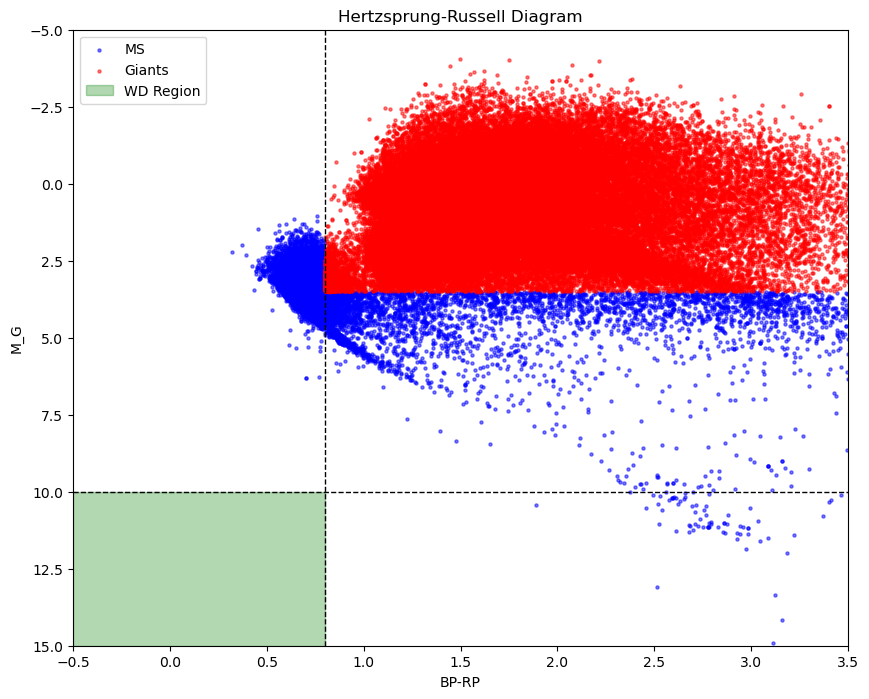

In [13]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')
data = hdul[1].data
colnames = hdul[1].columns.names

# Select data with good quality
starflag_mask = (data['STARFLAG'] == 0)
aspcapflag_mask = (data['ASPCAPFLAG'] == 0)
snr_mask = (data['SNR'] > 10)

parallax = data['GAIAEDR3_PARALLAX']
parallax_error = data['GAIAEDR3_PARALLAX_ERROR']
parallax_mask = (parallax_error > 0) & (np.abs(parallax / parallax_error) > 5)

g_not_nan = ~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])
bp_not_nan = ~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])
rp_not_nan = ~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG'])

good_mask = (starflag_mask & aspcapflag_mask & snr_mask & 
             parallax_mask & g_not_nan & bp_not_nan & rp_not_nan)
good_data = data[good_mask]

# Randomly select 80% of the good data
np.random.seed(42)
n_select = int(0.8 * len(good_data))
indices = np.random.choice(len(good_data), n_select, replace=False)
selected = good_data[indices]

# Calculate colour and absolute magnitude
bp = selected['GAIAEDR3_PHOT_BP_MEAN_MAG']
rp = selected['GAIAEDR3_PHOT_RP_MEAN_MAG']
g = selected['GAIAEDR3_PHOT_G_MEAN_MAG']
parallax = selected['GAIAEDR3_PARALLAX']

colour = bp - rp
abs_mag = g + 5 * np.log10(parallax / 1000) + 5

# Apply classification
giant = (abs_mag < 3.5) & (colour > 0.8)
ms = ~giant
wd = (colour <= 0.8) & (abs_mag > 10)

# Create the HR diagram
plt.figure(figsize=(10, 8))

# Plot main sequence (blue)
plt.scatter(colour[ms], abs_mag[ms], c='blue', s=5, alpha=0.5, label='MS')

# Plot giant branch (red)
plt.scatter(colour[giant], abs_mag[giant], c='red', s=5, alpha=0.5, label='Giants')

# Plot white dwarf region using fill_between
x_fill = np.linspace(-0.5, 0.8, 100)
y_fill_lower = 10
y_fill_upper = 15
plt.fill_between(x_fill, y_fill_lower, y_fill_upper, alpha=0.3, color='green', label='WD Region')

# Draw lines for WD region
plt.axvline(x=0.8, color='black', linestyle='--', linewidth=1)
plt.axhline(y=10, color='black', linestyle='--', linewidth=1)

# Invert y-axis
plt.gca().invert_yaxis()

# Set axis limits
plt.xlim(-0.5, 3.5)
plt.ylim(15, -5)

# Labels
plt.xlabel('BP-RP')
plt.ylabel('M_G')
plt.title('Hertzsprung-Russell Diagram')

# Legend
plt.legend()

plt.show()